In [1]:
## Interpolation Performance: Kriging vs IDW Interpolation Comparison

""" 
This script evaluates and compares the performance of two spatial interpolation methods—Ordinary Kriging and Inverse Distance Weighting (IDW)—applied to
hourly meteorological and precipitation-phase predictor variables. The analysis tests each method's ability to reproduce observed point data across space,
elevation, and time.

Processing Steps:
1. Load Kriging and IDW predictor grids; align spatial grids and time stamps
   to ensure 1:1 temporal correspondence.
2. Load hourly-level observational datasets and convert to long format for
   variable-wise comparison.
3. Extract elevation values for each observation point from the DEM to enable
   elevation-based diagnostics.
4. Subset all observations to the Kriging test window and enforce consistent
   time, coordinate, and variable naming conventions across sources.
5. For each variable and time step:
      a. Sample predicted values from both Kriging and IDW grids at the
         observation coordinates.
      b. Compute residuals (predicted - observed).
      c. Derive summary performance metrics:
         - RMSE (root mean square error)
         - MAE  (mean absolute error)
         - Bias (mean error)
         - N    (sample size)
6. Aggregate metrics by data source and variable to summarize comparative
   accuracy across interpolation methods.

Visualization & Diagnostics:
- RMSE barplots by variable and source to compare overall accuracy.
- Residual vs elevation scatterplots and smoothed mean trendlines to
  identify terrain-dependent bias.
- Boxplots of residuals by elevation band to highlight systematic
  over/under-prediction in lowland vs high-mountain regions.
"""

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import rasterio
import matplotlib.ticker as mticker
from statsmodels.distributions.empirical_distribution import ECDF
from matplotlib.colors import TwoSlopeNorm
import geopandas as gpd
from rasterio.plot import show as rio_show
from scipy.interpolate import griddata
import matplotlib.patches as mpatches


# PATHS
BASE_DIR = Path().resolve().parent

CONFIG = {
    "station_meta_csv": BASE_DIR / "Data/Stations/station_metadata_20241001_20250531.csv",
    "station_dir":      BASE_DIR / "Data/Stations",   # per-station CSVs
    "imerg_dir":        BASE_DIR / "Data/IMERG",      # parquet (wide)
    "mros_parquet":     BASE_DIR / "Data/observations/wy25_mros_obs.parquet",
    "dem_path":         BASE_DIR / "DEM_1km.tif",
    "out_dir":          BASE_DIR / "outputs/hourly_pipeline",
    "kriging_nc":       Path("C:/Users/EmmaGolub/Desktop/MRoS_local/local_data/kriging/test9_hourly_predictors_1km_kriging.nc"), # too large to store on github so saved locally and in Google Drive data folder
    "idw_nc":           Path("C:/Users/EmmaGolub/Desktop/MRoS_local/local_data/full_window/hourly_predictors_1km_IDW.nc") # too large to store on github so saved locally and in Google Drive data folder
}

VARS = ["mros_plp_proxy", "plp", "temp_air", "temp_wet", "temp_dew", "rh"]
XNAME, YNAME, TNAME = "x", "y", "time"

out_dir = Path(CONFIG["out_dir"])


In [2]:
# LOAD + ALIGN DATASETS
krig = xr.open_dataset(CONFIG["kriging_nc"])
idw  = xr.open_dataset(CONFIG["idw_nc"])
# print(krig["time"].values[:5])
# print(idw["time"].values[:5])

idw_sub = idw.sel({TNAME: krig[TNAME]})
krig = krig.sortby(TNAME)
idw_sub = idw_sub.sortby(TNAME)

# Align IDW with kriging test window
assert np.array_equal(krig[TNAME].values, idw_sub[TNAME].values)
print(idw_sub[TNAME].values[:20])


['2025-02-20T00:00:00.000000000' '2025-02-20T01:00:00.000000000'
 '2025-02-20T02:00:00.000000000' '2025-02-20T03:00:00.000000000'
 '2025-02-20T04:00:00.000000000' '2025-02-20T05:00:00.000000000'
 '2025-02-20T06:00:00.000000000' '2025-02-20T07:00:00.000000000'
 '2025-02-20T08:00:00.000000000' '2025-02-20T09:00:00.000000000'
 '2025-02-20T10:00:00.000000000' '2025-02-20T11:00:00.000000000'
 '2025-02-20T12:00:00.000000000' '2025-02-20T13:00:00.000000000'
 '2025-02-20T14:00:00.000000000' '2025-02-20T15:00:00.000000000'
 '2025-02-20T16:00:00.000000000' '2025-02-20T17:00:00.000000000'
 '2025-02-20T18:00:00.000000000' '2025-02-20T19:00:00.000000000']


In [3]:
# Load hourly-level stations, IMERG, and MRoS:
st_hr   = pd.read_parquet(out_dir / "hourly_data/stations_hourly.parquet")
imerg_hr = pd.read_parquet(out_dir / "hourly_data/imerg_hourly.parquet")
mros_hr     = pd.read_parquet(out_dir / "hourly_data/mros_hourly.parquet")

# Open DEM
dem_path = "C:/Users/EmmaGolub/Desktop/MRoS_local/local_data/DEM_AOI_TNM_10m.tif"

## already added...
# def add_elev_from_dem(df, dem_path, lon_col="lon", lat_col="lat"):
#     with rasterio.open(dem_path) as dem:
#         coords = list(zip(df[lon_col], df[lat_col]))
#         elev = np.array([val[0] for val in dem.sample(coords)])
#     return df.assign(elev=elev)

# mros_hr = add_elev_from_dem(mros_hr,   dem_path)
# imerg_hr = add_elev_from_dem(imerg_hr, dem_path)


In [4]:
# Stations: wide → long
station_vars = ["temp_air", "temp_wet", "temp_dew", "rh"]

st_long = st_hr.melt(
    id_vars=["id", "hour_utc", "lat", "lon", "elev"],
    value_vars=station_vars,
    var_name="var",
    value_name="obs_value"
)
st_long["source"] = "stations"

# IMERG points: wide → long
imerg_long = imerg_hr.melt(
    id_vars=["hour_utc", "lat", "lon", "elev"],
    value_vars=["plp"],
    var_name="var",
    value_name="obs_value"
)
imerg_long["source"] = "imerg_points"

# MRoS proxies: wide → long
mros_long = mros_hr.melt(
    id_vars=["hour_utc", "lat", "lon", "elev"],
    value_vars=["mros_plp_proxy"],
    var_name="var",
    value_name="obs_value"
)
mros_long["source"] = "mros"

st_long = st_long.rename(columns={"hour_utc": "time", "lat": "y", "lon": "x"})
imerg_long = imerg_long.rename(columns={"hour_utc": "time", "lat": "y", "lon": "x"})
mros_long  = mros_long.rename(columns={"hour_utc": "time", "lat": "y", "lon": "x"})

print(list(krig.data_vars))
print(st_long["var"].unique())
print(imerg_long["var"].unique())
print(mros_long["var"].unique())

print(st_long["time"].values[:5])
print(imerg_long["time"].values[:5])
print(mros_long["time"].values[:5])


['temp_air', 'temp_dew', 'temp_wet', 'rh', 'mros_plp_proxy', 'plp', 'elev', 'spatial_ref']
['temp_air' 'temp_wet' 'temp_dew' 'rh']
['plp']
['mros_plp_proxy']
['2024-10-01T08:00:00.000000000' '2024-10-01T09:00:00.000000000'
 '2024-10-01T10:00:00.000000000' '2024-10-01T11:00:00.000000000'
 '2024-10-01T12:00:00.000000000']
['2024-10-11T00:00:00.000000000' '2024-10-11T00:00:00.000000000'
 '2024-10-11T00:00:00.000000000' '2024-10-11T00:00:00.000000000'
 '2024-10-11T00:00:00.000000000']
['2024-10-06T21:00:00.000000000' '2024-10-06T21:00:00.000000000'
 '2024-10-06T23:00:00.000000000' '2024-10-07T01:00:00.000000000'
 '2024-10-07T02:00:00.000000000']


In [5]:
print("Krig dtype:", krig["time"].dtype)
print("IDW dtype:", idw_sub["time"].dtype)
print("Stations dtype:", st_long["time"].dtype)
print("IMERG dtype:", imerg_long["time"].dtype)
print("MRoS dtype:", mros_long["time"].dtype)

Krig dtype: datetime64[ns]
IDW dtype: datetime64[ns]
Stations dtype: datetime64[ns, UTC]
IMERG dtype: datetime64[ns, UTC]
MRoS dtype: datetime64[ns, UTC]


In [6]:
# Also align hourly datasets with testing window
for df in [st_long, imerg_long, mros_long]:
    df["time"] = pd.to_datetime(df["time"], utc=True) \
                   .dt.floor("h") \
                   .dt.tz_localize(None) # make tz naive
    
# Force to floats for all obs dataframes
for df in [st_long, imerg_long, mros_long]:
    df["x"] = pd.to_numeric(df["x"], errors="coerce")
    df["y"] = pd.to_numeric(df["y"], errors="coerce")


krig_times = pd.to_datetime(krig["time"].values)

st_long = st_long[st_long["time"].isin(krig_times)]
imerg_long = imerg_long[imerg_long["time"].isin(krig_times)]
mros_long  = mros_long[mros_long["time"].isin(krig_times)]

print(st_long.dtypes)
print(imerg_long.dtypes)
print(mros_long.dtypes)


id                   object
time         datetime64[ns]
y                   float64
x                   float64
elev                float64
var                  object
obs_value           float64
source               object
dtype: object
time         datetime64[ns]
y                   float64
x                   float64
elev                float32
var                  object
obs_value           float64
source               object
dtype: object
time         datetime64[ns]
y                   float64
x                   float64
elev                float32
var                  object
obs_value           float64
source               object
dtype: object


In [7]:
# VALIDATION + METRICS
def compute_metrics(err: np.ndarray) -> dict:
    return {
        "rmse": float(np.sqrt(np.nanmean(err**2))),
        "mae":  float(np.nanmean(np.abs(err))),
        "bias": float(np.nanmean(err)),
        "n":    int(np.sum(~np.isnan(err))),
    }

# Iterate over unique times in small batches to save memory
def sample_ds_at_points(ds: xr.Dataset, points_long: pd.DataFrame, var: str,
                        xname=XNAME, yname=YNAME, tname=TNAME) -> np.ndarray:
    sub = points_long.loc[points_long["var"] == var].copy()
    if sub.empty:
        return np.array([])
    
    results = []
    for t, sub_t in sub.groupby("time"):
        try:
            # select single time slice and reduce to 2D array, then interpolate slice at obs locations for that time
            f_time = ds[var].sel({tname: t}, method="nearest")
        except Exception:
            continue
        sampled = f_time.interp(
            {xname: xr.DataArray(sub_t[xname].values, dims="obs"),
             yname: xr.DataArray(sub_t[yname].values, dims="obs")}
        )
        results.append(pd.Series(sampled.values, index=sub_t.index))
    
    if results:
        return pd.concat(results).sort_index().values
    else:
        return np.array([])


# loop over each var and sample predictions from both kriging and IDW datasets at obs coordinates and times, then compare to observed values
def evaluate_source(points_long: pd.DataFrame, source_name: str, return_residuals=False) -> pd.DataFrame:
    rows = []
    resid_rows = []

    for var in sorted(set(points_long["var"]) & set(VARS)):
        pred_k = sample_ds_at_points(krig,   points_long, var)
        pred_i = sample_ds_at_points(idw_sub, points_long, var)
        sub = points_long.loc[points_long["var"] == var].copy()
        obs = sub["obs_value"].to_numpy(dtype=float)
        m = min(len(obs), len(pred_k), len(pred_i))
        obs, pred_k, pred_i = obs[:m], pred_k[:m], pred_i[:m]
        err_k, err_i = pred_k - obs, pred_i - obs

        rows += [
            {"source": source_name, "var": var, "method": "kriging", **compute_metrics(err_k)},
            {"source": source_name, "var": var, "method": "idw",     **compute_metrics(err_i)},
        ]
        
        if return_residuals:
            resid_rows.append(
                pd.DataFrame({
                    "source": source_name,
                    "var": var,
                    "time": sub["time"].values[:m],
                    "x": sub["x"].values[:m],
                    "y": sub["y"].values[:m],
                    "elev": sub["elev"].values[:m] if "elev" in sub.columns else np.full(m, np.nan),
                    "obs": obs,
                    "pred_krig": pred_k,
                    "pred_idw": pred_i,
                    "resid_krig": err_k,
                    "resid_idw": err_i,
                })
            )

    metrics = pd.DataFrame(rows)
    if return_residuals:
        return metrics, pd.concat(resid_rows, ignore_index=True)
    else:
        return metrics

In [8]:
# Run for each source, capturing metrics + residuals
metrics_stn,  resid_stn  = evaluate_source(st_long,   "stations", return_residuals=True)
metrics_mros, resid_mros = evaluate_source(mros_long, "mros", return_residuals=True)
metrics_imrg, resid_imrg = evaluate_source(imerg_long,"imerg_points", return_residuals=True)

# Combine all summary metrics
all_metrics = pd.concat([metrics_stn, metrics_mros, metrics_imrg], ignore_index=True)

# Combine all row-level residuals
all_residuals = pd.concat([resid_stn, resid_mros, resid_imrg], ignore_index=True)


In [25]:
# Plotting
# reshape residuals
def _to_long_residuals(resid_df):
    """Convert wide resid_krig / resid_idw into long format with 'method' + 'residual'."""
    df = resid_df.melt(
        id_vars=["source", "var", "time", "x", "y", "elev", "obs"],
        value_vars=["resid_krig", "resid_idw"],
        var_name="method", value_name="residual"
    )
    return df.replace({"resid_krig": "kriging", "resid_idw": "idw"})


PALETTE = {"kriging": "C0", "idw": "C1"}  # consistent colors

# # RMSE barplot
# def plot_rmse_bar(metrics_df, outdir=None, logscale=False, rmse_clip=500):
#     df = metrics_df.copy()
#     # Clip extreme RMSE values
#     df.loc[df["rmse"] > rmse_clip, "rmse"] = np.nan

#     g = sns.catplot(
#         data=df,
#         x="var", y="rmse", hue="method", col="source",
#         kind="bar", errorbar=None, height=4, aspect=1.2,
#         palette=PALETTE
#     )
#     if logscale:
#         g.set(yscale="log")
#     g.set_axis_labels("Variable", "RMSE")
#     g.set_titles("{col_name}")
#     plt.tight_layout()
#     if outdir:
#         g.savefig(Path(outdir) / "rmse_by_variable_source.png", dpi=200)
#     plt.show()

# # Residuals vs Elevation
# def plot_resid_vs_elev(resid_df, outdir=None):
#     if "elev" not in resid_df.columns:
#         print("No elevation column in data.")
#         return

#     df = _to_long_residuals(resid_df).dropna(subset=["elev"])

#     g = sns.FacetGrid(df, col="var", col_wrap=3, height=4, sharey=False)
#     g.map_dataframe(
#         sns.scatterplot,
#         x="elev", y="residual", hue="method",
#         alpha=0.4, s=15, palette=PALETTE
#     )
#     g.map_dataframe(
#         sns.lineplot,
#         x="elev", y="residual", hue="method",
#         estimator="mean", lw=2, palette=PALETTE, legend=False
#     )
#     for ax in g.axes.flatten():
#         ax.axhline(0, color="k", ls="--")
#     g.set_axis_labels("Elevation (m)", "Residual (pred - obs)")
#     g.add_legend(title="Method")
#     plt.tight_layout()
#     if outdir:
#         g.savefig(Path(outdir) / "residuals_vs_elevation_by_var.png", dpi=200)
#     plt.show()


# # Residuals by Elevation Band
# def plot_resid_box_by_band(resid_df, outdir=None, bins=(0,1500,2500,4000)):
#     if "elev" not in resid_df.columns:
#         print("No elevation column in data.")
#         return

#     df = _to_long_residuals(resid_df).dropna(subset=["elev"])
#     df["elev_band"] = pd.cut(df["elev"], bins=bins, include_lowest=True)
#     df["elev_band"] = df["elev_band"].astype(str)

#     g = sns.catplot(
#         data=df,
#         x="elev_band", y="residual", hue="method", col="var",
#         kind="box", col_wrap=3, height=4, sharey=False,
#         palette=PALETTE
#     )
#     for ax in g.axes.flatten():
#         ax.axhline(0, color="k", ls="--")
#     g.set_axis_labels("Elevation band (m)", "Residual (pred - obs)")
#     g.set_titles("{col_name}")
#     g.add_legend(title="Method")
#     plt.tight_layout()
#     if outdir:
#         g.savefig(Path(outdir) / "residuals_by_band_by_var.png", dpi=200)
#     plt.show()


# Method Advantage Plot (ΔRMSE)
def plot_rmse_difference(metrics_df, outdir=None):
    """
    Plot ΔRMSE = RMSE_IDW - RMSE_Kriging for each variable and source.
    Negative values indicate Kriging performs better (lower RMSE).
    """
    df = metrics_df.pivot_table(index=["var"], columns="method", values="rmse").reset_index()
    df["ΔRMSE"] = df["idw"] - df["kriging"]

    g = sns.catplot(
        data=df,
        x="var", y="ΔRMSE",
        kind="bar", height=4, aspect=1.3, palette="Set2"
    )
    g.set_axis_labels("Variable", "ΔRMSE (IDW − Kriging)")
    g.map_dataframe(lambda data, color, **kws: plt.axhline(0, color="k", lw=1, ls="--"))
    g.set_titles("{col_name}")
    g.set(ylim=(-max(abs(df["ΔRMSE"])) * 1.1, max(abs(df["ΔRMSE"])) * 1.1))
    plt.tight_layout()

    if outdir:
        g.savefig(Path(outdir) / "rmse_difference_by_var.png", dpi=200)
    plt.show()


# Heatmap of RMSE by Variable × Elevation Band
def plot_rmse_heatmap_by_elev(resid_df, outdir=None, bins=(0,1500,2500,4000)):
    """
    Show RMSE variation by elevation band and variable for each method.
    Useful for visualizing which methods perform best across terrain classes.
    """
    df = _to_long_residuals(resid_df).dropna(subset=["elev"])
    df["elev_band"] = pd.cut(df["elev"], bins=bins, include_lowest=True, labels=False)
    df["elev_band_str"] = pd.cut(df["elev"], bins=bins, include_lowest=True).astype(str)

    rmse_stats = (
        df.groupby(["method", "var", "elev_band_str"])
          .agg(rmse=("residual", lambda x: np.sqrt(np.nanmean(x**2))))
          .reset_index()
    )

    for method in rmse_stats["method"].unique():
        subset = rmse_stats[rmse_stats["method"] == method]
        pivot = subset.pivot(index="var", columns="elev_band_str", values="rmse")
        plt.figure(figsize=(7, 4))
        sns.heatmap(
            pivot, annot=True, fmt=".2f", cmap="coolwarm_r",
            cbar_kws={"label": "RMSE"}, linewidths=0.3
        )
        plt.title(f"RMSE by Variable and Elevation Band ({method})")
        plt.xlabel("Elevation band (m)")
        plt.ylabel("Variable")
        plt.tight_layout()

        if outdir:
            plt.savefig(Path(outdir) / f"rmse_heatmap_by_elev_{method}.png", dpi=200)
        plt.show()

      
# Spatial Mean Residual Maps
def plot_spatial_mean_residuals(resid_df, outdir=None, var_subset=None, vlim=None):
    """
    Plot mean residuals across all timesteps for each variable and method,
    revealing spatial structure in bias (over/under-prediction zones).
    """
    df = _to_long_residuals(resid_df).dropna(subset=["x", "y", "residual"])
    if var_subset:
        df = df[df["var"].isin(var_subset)]

    mean_resid = (
        df.groupby(["method", "var", "x", "y"])["residual"]
        .mean()
        .reset_index()
    )

    for var in sorted(df["var"].unique()):
        plt.figure(figsize=(10, 4))
        for i, method in enumerate(["kriging", "idw"], start=1):
            sub = mean_resid[(mean_resid["var"] == var) & (mean_resid["method"] == method)]
            plt.subplot(1, 2, i)
            norm = TwoSlopeNorm(vcenter=0, vmin=vlim[0] if vlim else sub["residual"].quantile(0.05),
                                vmax=vlim[1] if vlim else sub["residual"].quantile(0.95))
            sc = plt.scatter(sub["x"], sub["y"], c=sub["residual"], cmap="coolwarm", s=10, norm=norm)
            plt.title(f"{method.capitalize()} – {var}")
            plt.axis("equal")
            plt.xlabel("Longitude")
            plt.ylabel("Latitude")
            plt.colorbar(sc, label="Mean residual (pred − obs)")
        plt.suptitle(f"Spatial Mean Residuals: {var}", y=1.02, fontsize=13)
        plt.tight_layout()
        if outdir:
            plt.savefig(Path(outdir) / f"spatial_mean_residuals_{var}.png", dpi=250)
        plt.show()


# Temporal RMSE Trends by Hour
def plot_rmse_by_hour(resid_df, outdir=None):
    """
    Plot RMSE as a function of hour-of-day (UTC) for each variable and method.
    Helps identify diurnal patterns or time-of-day biases in interpolation.
    """
    df = _to_long_residuals(resid_df).dropna(subset=["time", "residual"])
    df["hour"] = pd.to_datetime(df["time"]).dt.hour

    hourly_rmse = (
        df.groupby(["method", "var", "hour"])
        .agg(rmse=("residual", lambda x: np.sqrt(np.nanmean(x**2))))
        .reset_index()
    )

    g = sns.FacetGrid(hourly_rmse, col="var", col_wrap=3, height=4, sharey=False)
    g.map_dataframe(
        sns.lineplot,
        x="hour", y="rmse", hue="method", lw=2, palette=PALETTE, marker="o"
    )
    g.add_legend(title="Method")
    g.set_axis_labels("Hour (UTC)", "RMSE")
    g.set_titles("{col_name}")
    g.set(xlim=(0, 23), xticks=[0, 6, 12, 18, 23])
    g.tight_layout()
    if outdir:
        g.savefig(Path(outdir) / "rmse_by_hour.png", dpi=250)
    plt.show()


# Residual vs Predicted (Error Shape) Diagnostics
def plot_residual_vs_predicted(resid_df, outdir=None, sample_frac=0.3):
    """
    Plot residual vs predicted values for each variable and method.
    Reveals heteroscedasticity and bias trends (e.g., underpredicting highs).
    """
    df = resid_df.copy()
    # Compute predicted values for each method
    df_long = df.melt(
        id_vars=["source", "var", "time", "x", "y", "elev", "obs"],
        value_vars=["pred_krig", "pred_idw"],
        var_name="method", value_name="predicted"
    )
    df_long["method"] = df_long["method"].replace({"pred_krig": "kriging", "pred_idw": "idw"})
    df_long["residual"] = df_long["predicted"] - df_long["obs"]
    df_long = df_long.dropna(subset=["predicted", "residual"])

    # Optionally downsample for dense hourly datasets
    if sample_frac < 1.0:
        df_long = df_long.sample(frac=sample_frac, random_state=42)

    for var in sorted(df_long["var"].unique()):
        g = sns.lmplot(
            data=df_long[df_long["var"] == var],
            x="predicted", y="residual", hue="method",
            lowess=True, scatter_kws={"alpha": 0.3, "s": 20},
            line_kws={"lw": 2}, height=4.5, aspect=1.2, palette=PALETTE
        )
        plt.axhline(0, color="k", ls="--", lw=1)
        plt.title(f"Residual vs Predicted: {var}")
        plt.tight_layout()
        if outdir:
            plt.savefig(Path(outdir) / f"residual_vs_predicted_{var}.png", dpi=250)
        plt.show()



# Residual Bias Landscapes (Spatially Interpolated)
def plot_residual_bias_landscapes(resid_df, dem_path, outdir=None,
                                  var_subset=None, grid_res=0.02,
                                  method_interp="linear", vlim=None):
    """
    Interpolates mean residuals (pred−obs) to a regular grid and overlays
    them on the DEM, showing terrain-linked bias patterns.
    """
    df = _to_long_residuals(resid_df).dropna(subset=["x", "y", "residual"])
    if var_subset:
        df = df[df["var"].isin(var_subset)]

    # Compute mean residual at each point
    mean_resid = (
        df.groupby(["method", "var", "x", "y"])["residual"]
          .mean()
          .reset_index()
    )

    # Load DEM for background
    with rasterio.open(dem_path) as dem:
        dem_data = dem.read(1)
        dem_extent = (dem.bounds.left, dem.bounds.right, dem.bounds.bottom, dem.bounds.top)

    # Determine grid domain
    xgrid = np.arange(df["x"].min(), df["x"].max(), grid_res)
    ygrid = np.arange(df["y"].min(), df["y"].max(), grid_res)
    gx, gy = np.meshgrid(xgrid, ygrid)

    for var in sorted(mean_resid["var"].unique()):
        for method in ["kriging", "idw"]:
            sub = mean_resid[(mean_resid["var"] == var) & (mean_resid["method"] == method)]
            if sub.empty:
                continue

            # Interpolate residuals to grid
            zi = griddata(
                points=sub[["x", "y"]].values,
                values=sub["residual"].values,
                xi=(gx, gy),
                method=method_interp
            )

            # Define symmetric color scale
            vmin = vlim[0] if vlim else np.nanquantile(zi, 0.05)
            vmax = vlim[1] if vlim else np.nanquantile(zi, 0.95)
            vmax = max(abs(vmin), abs(vmax))
            vmin = -vmax

            plt.figure(figsize=(8, 6))
            rio_show(dem_data, extent=dem_extent, cmap="Greys", alpha=0.35)
            plt.imshow(
                np.flipud(zi),
                extent=[xgrid.min(), xgrid.max(), ygrid.min(), ygrid.max()],
                cmap="coolwarm", vmin=vmin, vmax=vmax, alpha=0.9
            )
            plt.colorbar(label="Mean residual (pred − obs)")
            plt.title(f"{var} – {method.capitalize()} residual bias over DEM")
            plt.xlabel("Longitude")
            plt.ylabel("Latitude")
            plt.tight_layout()
            if outdir:
                plt.savefig(Path(outdir) / f"residual_bias_landscape_{var}_{method}.png", dpi=300)
            plt.show()



# Radar / Spider Plot: Multi-Metric Summary
def plot_radar_summary(metrics_df, outdir=None, normalize=True):
    """
    Create radar (spider) charts comparing Kriging vs IDW across variables
    and metrics (RMSE, MAE, Bias).

    Parameters
    ----------
    metrics_df : DataFrame
        Combined metrics dataframe (from evaluate_source).
    outdir : str or Path, optional
        Directory to save plots.
    normalize : bool, optional
        Normalize each metric (per variable) to [0,1] for comparability.
    """
    # Aggregate metrics by variable & method (averaged across sources)
    df = (
        metrics_df.groupby(["method", "var"])
        [["rmse", "mae", "bias"]]
        .mean()
        .reset_index()
    )

    # Normalize metrics if requested
    if normalize:
        df_norm = df.copy()
        for col in ["rmse", "mae", "bias"]:
            col_range = df[col].max() - df[col].min()
            df_norm[col] = (df[col] - df[col].min()) / (col_range if col_range != 0 else 1)
        df = df_norm

    # Radar setup
    metrics = ["rmse", "mae", "bias"]
    num_metrics = len(metrics)
    angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
    angles += angles[:1]  # close loop

    methods = sorted(df["method"].unique())
    vars_ = sorted(df["var"].unique())

    # Create one subplot per variable
    ncols = 3
    nrows = int(np.ceil(len(vars_) / ncols))
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        subplot_kw=dict(polar=True),
        figsize=(4*ncols, 4*nrows)
    )
    axes = np.atleast_1d(axes).flatten()

    for i, var in enumerate(vars_):
        ax = axes[i]
        for method in methods:
            sub = df[df["var"] == var].set_index("method").loc[method, metrics]
            values = sub.tolist() + [sub.tolist()[0]]
            ax.plot(angles, values, lw=2, label=method)
            ax.fill(angles, values, alpha=0.2)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(metrics, fontsize=10)
        ax.set_title(var, size=12, pad=12)
        ax.set_ylim(0, 1 if normalize else None)
        ax.grid(True, alpha=0.3)

    # Legend and layout
    handles = [mpatches.Patch(color=PALETTE[m], label=m) for m in methods if m in PALETTE]
    fig.legend(handles=handles, loc="upper right", bbox_to_anchor=(1.15, 1))
    fig.suptitle("Interpolation Performance Summary (Radar Chart)", fontsize=14, y=1.02)
    plt.tight_layout()

    if outdir:
        plt.savefig(Path(outdir) / "radar_summary_metrics.png", dpi=300, bbox_inches="tight")
    plt.show()



Plotting radar (spider) summary chart...


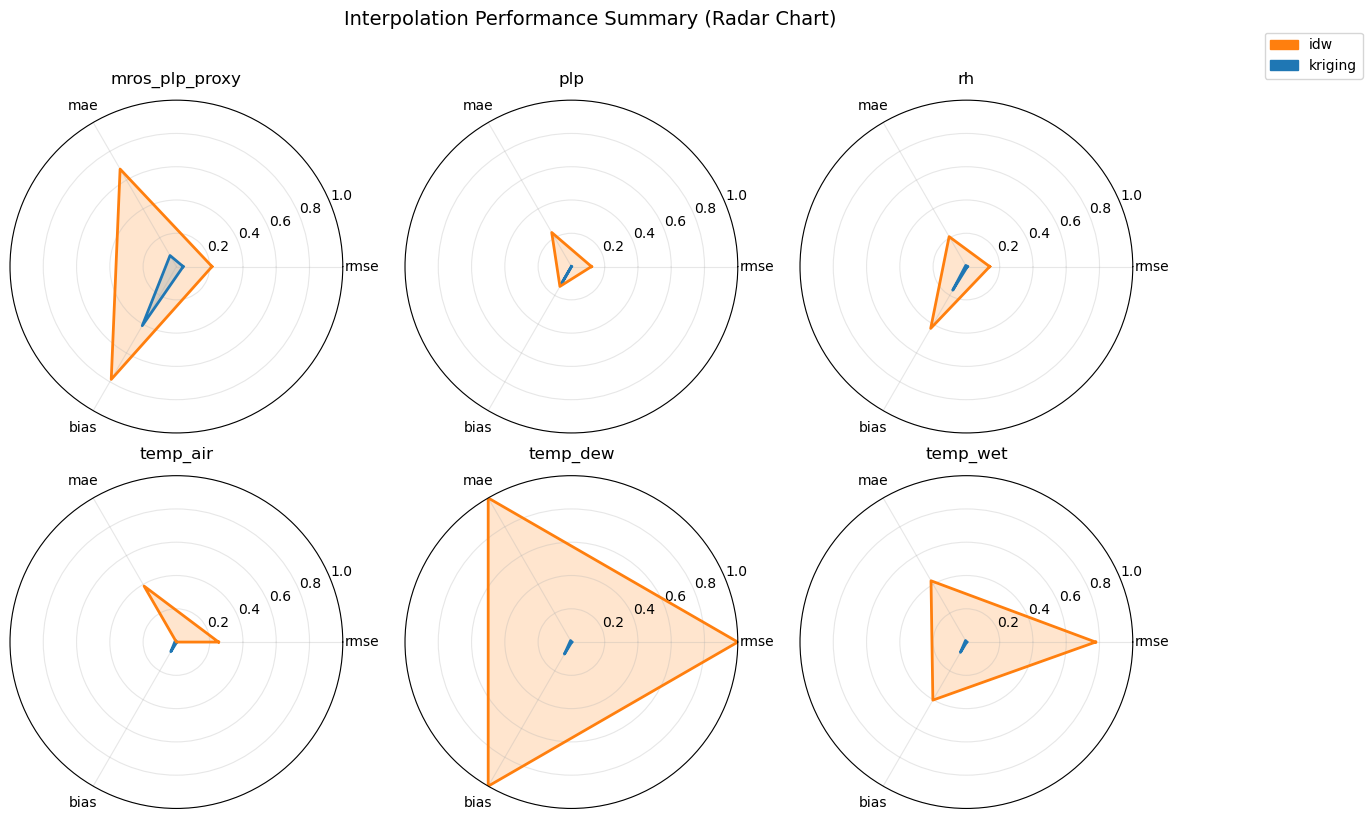

In [ ]:
print("Plotting radar (spider) summary chart...")
plot_radar_summary(all_metrics, outdir=out_dir, normalize=True)

print("Plotting ΔRMSE method advantage plot...")
plot_rmse_difference(all_metrics, outdir=out_dir)

print("Plotting RMSE heatmaps by elevation band...")
plot_rmse_heatmap_by_elev(all_residuals, outdir=out_dir)

print("Plotting spatial mean residual maps...")
plot_spatial_mean_residuals(all_residuals, outdir=out_dir, var_subset=None)

print("Plotting RMSE trends by hour...")
plot_rmse_by_hour(all_residuals, outdir=out_dir)

print("Plotting residual vs predicted diagnostics...")
plot_residual_vs_predicted(all_residuals, outdir=out_dir)

print("Plotting residual bias landscapes over DEM...")
plot_residual_bias_landscapes(
    all_residuals,
    dem_path=CONFIG["dem_path"],
    outdir=out_dir,
    var_subset=None,  # or None for all
    grid_res=0.02,    # adjust for your domain size
    method_interp="linear"
)


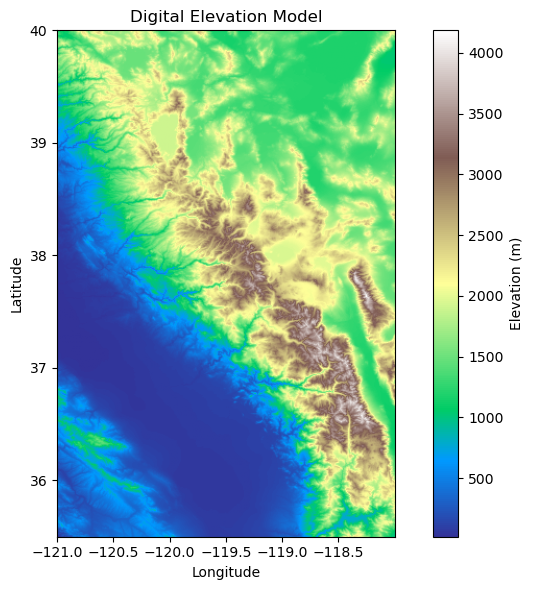

In [ ]:
import rasterio
from rasterio.plot import show as rio_show
import matplotlib.pyplot as plt

dem_path = CONFIG["dem_path"]

with rasterio.open(dem_path) as dem:
    dem_data = dem.read(1)
    dem_extent = (dem.bounds.left, dem.bounds.right, dem.bounds.bottom, dem.bounds.top)

plt.figure(figsize=(8, 6))
img = plt.imshow(
    dem_data,
    cmap="terrain",  
    extent=dem_extent,
    origin="upper"
)
plt.colorbar(img, label="Elevation (m)")
plt.title("Digital Elevation Model")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()
